In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import folium
import wordcloud

constructors = pd.read_csv('collection/clean_data/constructors.csv')
raceResults = pd.read_csv('collection/clean_data/results.csv')
drivers = pd.read_csv('collection/clean_data/drivers.csv')
races = pd.read_csv('collection/clean_data/races.csv')
circuits = pd.read_csv('collection/clean_data/circuits.csv')
drivers_standings = pd.read_csv('collection/clean_data/drivers_standings.csv')
constructors_standings = pd.read_csv('collection/clean_data/constructors_standings.csv')

In [17]:
team_mapping = {
    'McLaren': 'McLaren',
    'McLaren-Ford': 'McLaren',
    'McLaren-Alfa Romeo': 'McLaren',
    'McLaren-Serenissima': 'Mclaren',
    'McLaren-BRM': 'McLaren',
    'Team Lotus': 'Lotus',
    'Lotus-Climax':'Lotus',
    'Lotus-Maserati':'Lotus',
    'Lotus-BRM':'Lotus',
    'Lotus-Borgward':'Lotus',
    'Lotus-Ford':'Lotus',
    'Lotus-Pratt &amp; Whitney':'Lotus',
    'Lotus': 'Lotus',
    'Lotus F1':'Lotus'
}
constructors['nam'] = constructors['name'].replace(team_mapping)


C:\Users\Iva Nikolova\AppData\Local\Temp\ipykernel_26132\3632649084.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winners_top_5['cumulative_wins'] = winners_top_5.groupby('name_y')['wins'].cumsum()
c:\Users\Iva Nikolova\Downloads\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Iva Nikolova\Downloads\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as

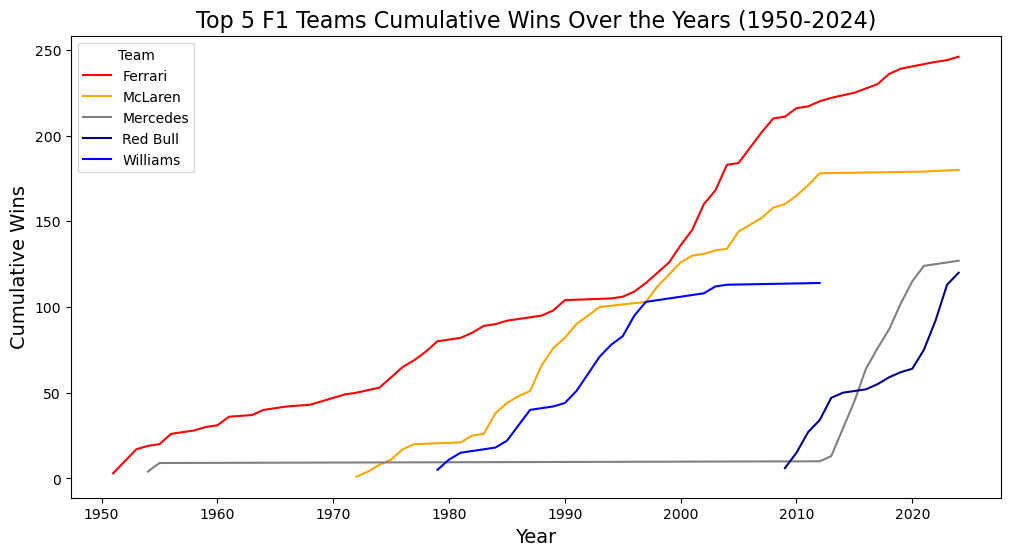

In [18]:
winners = raceResults[raceResults['position'] == '1']

winners = winners.merge(races, on='raceId', how='inner')

winners = winners.merge(constructors, on='constructorId', how='inner')
winners = winners[['name_y', 'year']]
winners = winners.groupby(['name_y', 'year']).size().reset_index(name='wins')

winners_grouped = winners.groupby(['name_y', 'year'])['wins'].sum().reset_index()

total_wins = winners_grouped.groupby('name_y')['wins'].sum().reset_index()

top_5_teams = total_wins.nlargest(5, 'wins')['name_y']

winners_top_5 = winners_grouped[winners_grouped['name_y'].isin(top_5_teams)]

winners_top_5['cumulative_wins'] = winners_top_5.groupby('name_y')['wins'].cumsum()

color_mapping = {
    'Ferrari': 'red',
    'McLaren': 'orange',
    'Mercedes': 'grey',
    'Red Bull': 'darkblue',
    'Williams': 'blue'
}

plt.figure(figsize=(12, 6))

sns.lineplot(data=winners_top_5, x='year', y='cumulative_wins', hue='name_y', palette=color_mapping)

plt.title('Top 5 F1 Teams Cumulative Wins Over the Years (1950-2024)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Cumulative Wins', fontsize=14)
plt.legend(title='Team')

plt.show()

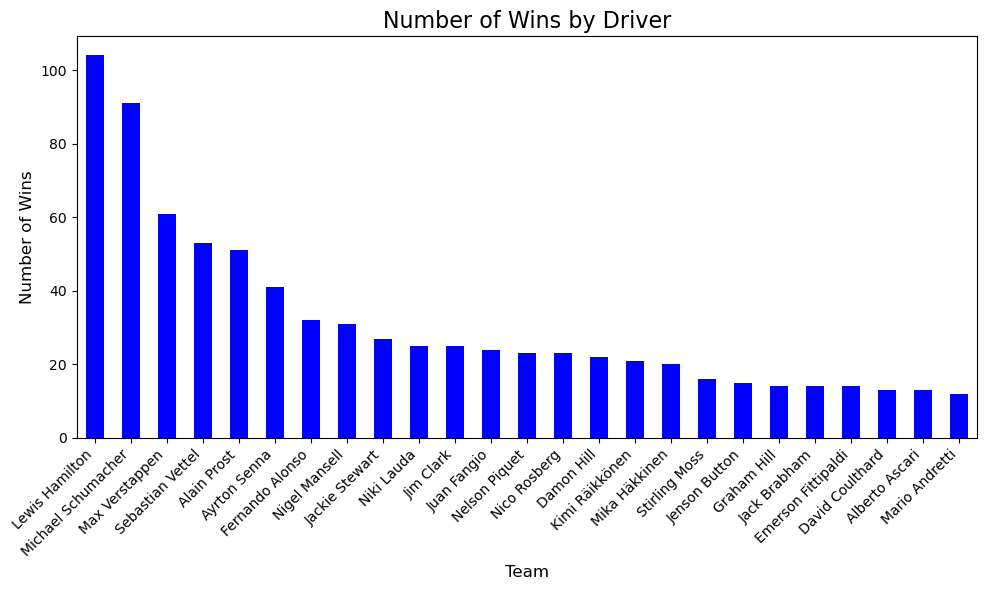

In [19]:
winners = raceResults[raceResults['position'] == '1']
winners = winners[['driverId']]

winners = winners.merge(drivers, on='driverId', how='inner')
winners['Full_Name'] = winners['forename'].astype(str) + ' ' + winners['surname'].astype(str)
driver_wins = winners['Full_Name'].value_counts()
top_25_drivers = driver_wins.head(25)

plt.figure(figsize=(10, 6))
top_25_drivers.plot(kind='bar', color='blue')

plt.title('Number of Wins by Driver', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

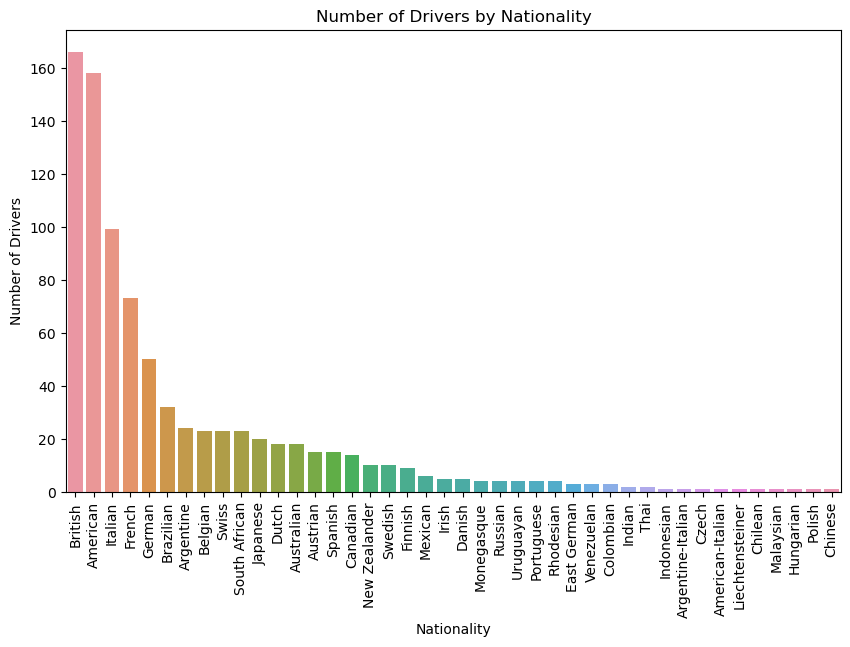

In [20]:
# Number of drivers by Nationaly
nationality_counts = drivers['nationality'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=nationality_counts.index, y=nationality_counts.values)
plt.title('Number of Drivers by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Drivers')
plt.xticks(rotation=90)
plt.show()

In [21]:
unique_years = races['year'].unique()
print("Available years in the dataset: ", unique_years)

races_per_year = races[races['year'] == 2020]

# Select the relevant columns
races_per_year_info = races_per_year[['name', 'date']]

# Display the results
print("Races in 2020:")
print(races_per_year_info.reset_index(drop=True))

Available years in the dataset:  [2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996
 1995 1994 1993 1992 1991 1990 2010 1989 1988 1987 1986 1985 1984 1983
 1982 1981 1980 1979 1978 1977 1976 1975 1974 1973 1972 1971 1970 1969
 1968 1967 1966 1965 1964 1963 1962 1961 1960 1959 1958 1957 1956 1955
 1954 1953 1952 1951 1950 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024]
Races in 2020:
                           name        date
0           Austrian Grand Prix  2020-07-05
1            Styrian Grand Prix  2020-07-12
2          Hungarian Grand Prix  2020-07-19
3            British Grand Prix  2020-08-02
4   70th Anniversary Grand Prix  2020-08-09
5            Spanish Grand Prix  2020-08-16
6            Belgian Grand Prix  2020-08-30
7            Italian Grand Prix  2020-09-06
8             Tuscan Grand Prix  2020-09-13
9            Russian Grand Prix  2020-09-27
10             Eifel Grand Prix  2020-10-11
11        Portuguese Grand Prix  2020-10-2

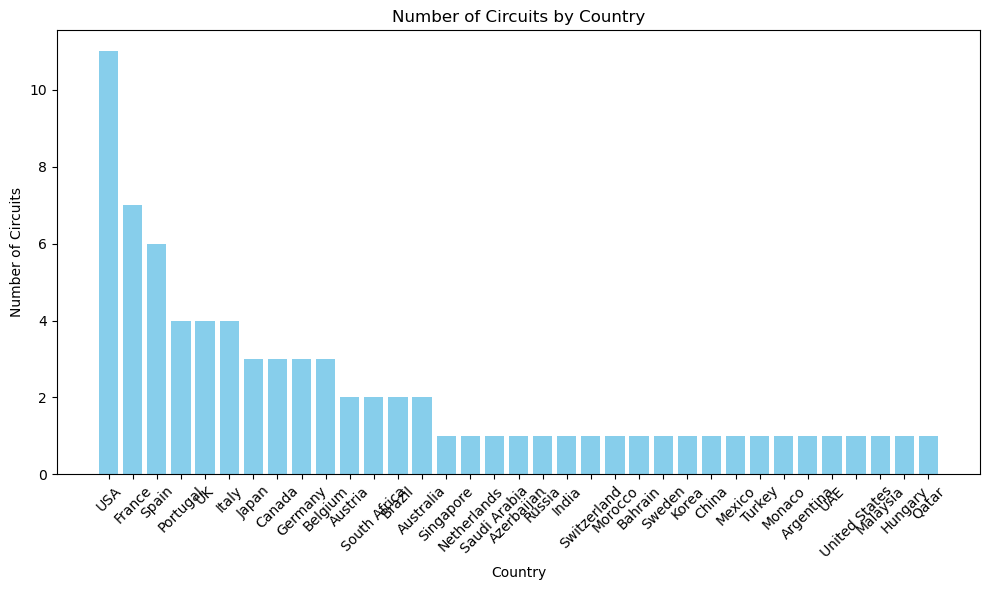

In [22]:
# Count the number of circuits by country
circuit_counts = circuits['country'].value_counts()

# Convert the Series to a DataFrame for easier manipulation
circuit_counts_df = circuit_counts.reset_index()
circuit_counts_df.columns = ['Country', 'Number of Circuits']

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(circuit_counts_df['Country'], circuit_counts_df['Number of Circuits'], color='skyblue')
plt.xlabel('Country')
plt.ylabel('Number of Circuits')
plt.title('Number of Circuits by Country')
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

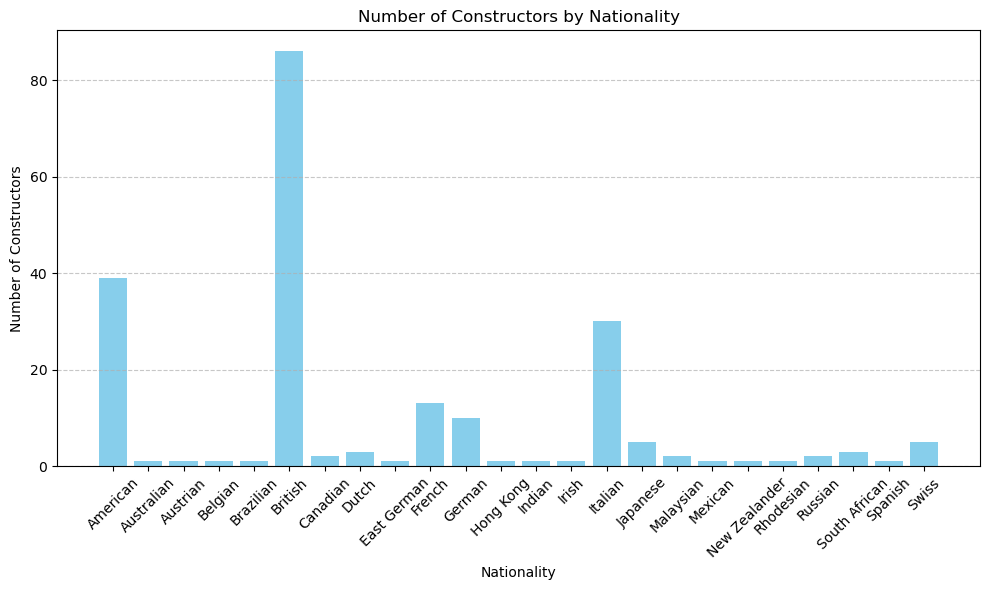

In [23]:
# Group by nationality
constructor_count = (
    constructors.groupby('nationality')
    .agg(
        Number_of_Constructors=('constructorId', 'size'),
        Constructor_Names=('name', lambda x: ', '.join(x))
    )
    .reset_index()
)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(constructor_count['nationality'], constructor_count['Number_of_Constructors'], color='skyblue')
plt.title('Number of Constructors by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Constructors')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [24]:
# Nationality to ISO 3166-1 alpha-3 country code mapping
nationality_to_iso3 = {
    'Afghan': 'AFG',
    'Albanian': 'ALB',
    'Algerian': 'DZA',
    'American': 'USA',
    'Andorran': 'AND',
    'Angolan': 'AGO',
    'Argentine': 'ARG',
    'Armenian': 'ARM',
    'Australian': 'AUS',
    'Austrian': 'AUT',
    'Azerbaijani': 'AZE',
    'Bahamian': 'BHS',
    'Bahraini': 'BHR',
    'Bangladeshi': 'BGD',
    'Barbadian': 'BRB',
    'Belarusian': 'BLR',
    'Belgian': 'BEL',
    'Belizean': 'BLZ',
    'Beninese': 'BEN',
    'Bhutanese': 'BTN',
    'Bolivian': 'BOL',
    'Bosnian': 'BIH',
    'Botswanan': 'BWA',
    'Brazilian': 'BRA',
    'British': 'GBR',
    'Bruneian': 'BRN',
    'Bulgarian': 'BGR',
    'Burkinabé': 'BFA',
    'Burundian': 'BDI',
    'Cabo Verdean': 'CPV',
    'Cambodian': 'KHM',
    'Canadian': 'CAN',
    'Central African': 'CAF',
    'Chadian': 'TCD',
    'Chilean': 'CHL',
    'Chinese': 'CHN',
    'Colombian': 'COL',
    'Comorian': 'COM',
    'Congolese': 'COG',
    'Costa Rican': 'CRI',
    'Croatian': 'HRV',
    'Cuban': 'CUB',
    'Cypriot': 'CYP',
    'Czech': 'CZE',
    'Danish': 'DNK',
    'Djiboutian': 'DJI',
    'Dominican': 'DOM',
    'Dutch': 'NLD',
    'Ecuadorian': 'ECU',
    'Egyptian': 'EGY',
    'Salvadoran': 'SLV',
    'Equatorial Guinean': 'GNQ',
    'Eritrean': 'ERI',
    'Estonian': 'EST',
    'Eswatini': 'SWZ',
    'Ethiopian': 'ETH',
    'Fijian': 'FJI',
    'Finnish': 'FIN',
    'French': 'FRA',
    'Gabonese': 'GAB',
    'Gambian': 'GMB',
    'Georgian': 'GEO',
    'German': 'DEU',
    'Ghanaian': 'GHA',
    'Greek': 'GRC',
    'Grenadian': 'GRD',
    'Guatemalan': 'GTM',
    'Guinean': 'GIN',
    'Haitian': 'HTI',
    'Honduran': 'HND',
    'Hungarian': 'HUN',
    'Icelandic': 'ISL',
    'Indian': 'IND',
    'Indonesian': 'IDN',
    'Iranian': 'IRN',
    'Iraqi': 'IRQ',
    'Irish': 'IRL',
    'Israeli': 'ISR',
    'Italian': 'ITA',
    'Ivorian': 'CIV',
    'Jamaican': 'JAM',
    'Japanese': 'JPN',
    'Jordanian': 'JOR',
    'Kazakh': 'KAZ',
    'Kenyan': 'KEN',
    'Kuwaiti': 'KWT',
    'Kyrgyz': 'KGZ',
    'Laotian': 'LAO',
    'Latvian': 'LVA',
    'Lebanese': 'LBN',
    'Liberian': 'LBR',
    'Libyan': 'LBY',
    'Lithuanian': 'LTU',
    'Luxembourger': 'LUX',
    'Malawian': 'MWI',
    'Malaysian': 'MYS',
    'Malian': 'MLI',
    'Maldivian': 'MDV',
    'Maltese': 'MLT',
    'Mexican': 'MEX',
    'Moldovan': 'MDA',
    'Monacan': 'MCO',
    'Mongolian': 'MNG',
    'Moroccan': 'MAR',
    'Mozambican': 'MOZ',
    'Namibian': 'NAM',
    'Nauruan': 'NRU',
    'Nepalese': 'NPL',
    'New Zealander': 'NZL',
    'Nigerien': 'NER',
    'Nigerian': 'NGA',
    'North Korean': 'PRK',
    'Norwegian': 'NOR',
    'Omani': 'OMN',
    'Pakistani': 'PAK',
    'Panamanian': 'PAN',
    'Papua New Guinean': 'PNG',
    'Paraguayan': 'PRY',
    'Peruvian': 'PER',
    'Philippine': 'PHL',
    'Polish': 'POL',
    'Portuguese': 'PRT',
    'Qatari': 'QAT',
    'Romanian': 'ROU',
    'Russian': 'RUS',
    'Rwandan': 'RWA',
    'Saudi': 'SAU',
    'Senegalese': 'SEN',
    'Serbian': 'SRB',
    'Seychellois': 'SYC',
    'Sierra Leonean': 'SLE',
    'Singaporean': 'SGP',
    'Slovak': 'SVK',
    'Slovenian': 'SVN',
    'Somali': 'SOM',
    'South African': 'ZAF',
    'South Korean': 'KOR',
    'Spanish': 'ESP',
    'Sri Lankan': 'LKA',
    'Sudanese': 'SDN',
    'Surinamese': 'SUR',
    'Swedish': 'SWE',
    'Swiss': 'CHE',
    'Syrian': 'SYR',
    'Taiwanese': 'TWN',
    'Tajik': 'TJK',
    'Tanzanian': 'TZA',
    'Thai': 'THA',
    'Togolese': 'TGO',
    'Trinidadian': 'TTO',
    'Tunisian': 'TUN',
    'Turkish': 'TUR',
    'Turkmen': 'TKM',
    'Ugandan': 'UGA',
    'Ukrainian': 'UKR',
    'Emirati': 'ARE',
    'Uruguayan': 'URY',
    'Uzbek': 'UZB',
    'Venezuelan': 'VEN',
    'Vietnamese': 'VNM',
    'Yemeni': 'YEM',
    'Zambian': 'ZMB',
    'Zimbabwean': 'ZWE'
}


In [25]:
map_data = drivers.groupby('nationality').size().reset_index(name='number')

geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json'
response = requests.get(geojson_url)

map_data['country_code'] = map_data['nationality'].map(nationality_to_iso3)
map_data = map_data[['number','country_code']]
map_data = map_data.dropna(subset=['country_code'])
geojson = response.json()

In [26]:
M = folium.Map(location=[20,10], zoom_start=2)

# Create the Choropleth layer
folium.Choropleth(
    geo_data=geojson,
    data=map_data,
    columns=['country_code', 'number'],
    key_on='feature.id',
    fill_color='YlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
).add_to(M)

M

In [27]:
# Step 1: Aggregate the number of teams by nationality
team_data = constructors.groupby('nationality').size().reset_index(name='number')

# Step 2: Map nationalities to ISO3 country codes
team_data['country_code'] = team_data['nationality'].map(nationality_to_iso3)
# Remove rows with no country code
team_data = team_data.dropna(subset=['country_code'])

# Step 3: Fetch GeoJSON data for countries
geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json'
response = requests.get(geojson_url)
geojson = response.json()

# Step 4: Create the Folium Map
M = folium.Map(location=[20, 10], zoom_start=2)

# Add Choropleth layer for team counts by country
folium.Choropleth(
    geo_data=geojson,
    data=team_data,
    columns=['country_code', 'number'],
    key_on='feature.id',
    fill_color='YlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Number of Teams by Nationality'
).add_to(M)

# Display the map
M

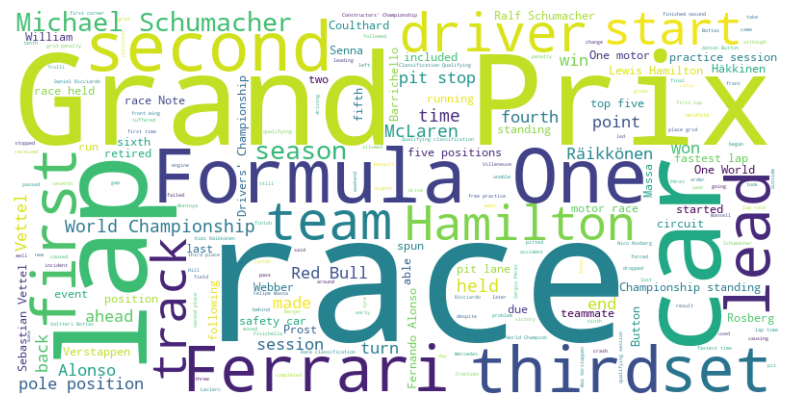

In [6]:
all_text = " ".join(str(row) for row in races['summary'].fillna(''))

wordcloud = wordcloud.WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [7]:
na_rows = races[races['summary'].isna()]

# Display the rows
print(na_rows)

      raceId  year  round  circuitId                    name        date  \
1054    1070  2021     18         32  Mexico City Grand Prix  2021-11-07   
1055    1071  2021     19         18    São Paulo Grand Prix  2021-11-14   
1076    1094  2022     20         32  Mexico City Grand Prix  2022-10-30   
1077    1095  2022     21         18    São Paulo Grand Prix  2022-11-13   
1098    1118  2023     20         18    São Paulo Grand Prix  2023-11-05   
1120    1140  2024     20         32  Mexico City Grand Prix  2024-10-27   
1121    1141  2024     21         18    São Paulo Grand Prix  2024-11-03   
1122    1142  2024     22         80    Las Vegas Grand Prix  2024-11-23   
1123    1143  2024     23         78        Qatar Grand Prix  2024-12-01   
1124    1144  2024     24         24    Abu Dhabi Grand Prix  2024-12-08   

                                                    url summary  
1054  http://en.wikipedia.org/wiki/2021_Mexican_Gran...     NaN  
1055  http://en.wikipedia.org/w

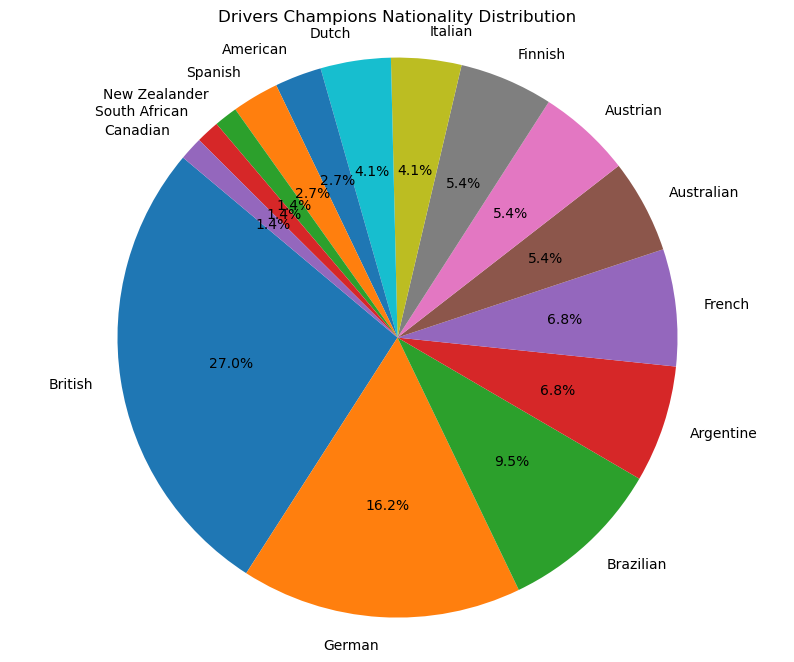

In [29]:
drivers_standings = drivers_standings[drivers_standings['position'] == 1]

drivers_nationality = drivers_standings.merge(drivers, on='driverId', how='inner')
drivers_nationality = drivers_nationality[['nationality']]

nationality_count_df = drivers_nationality['nationality'].value_counts().reset_index()
nationality_count_df.columns = ['nationality', 'count']

plt.figure(figsize=(10, 8))
plt.pie(nationality_count_df['count'], labels=nationality_count_df['nationality'], autopct='%1.1f%%', startangle=140)
plt.title('Drivers Champions Nationality Distribution')
plt.axis('equal')
plt.show()


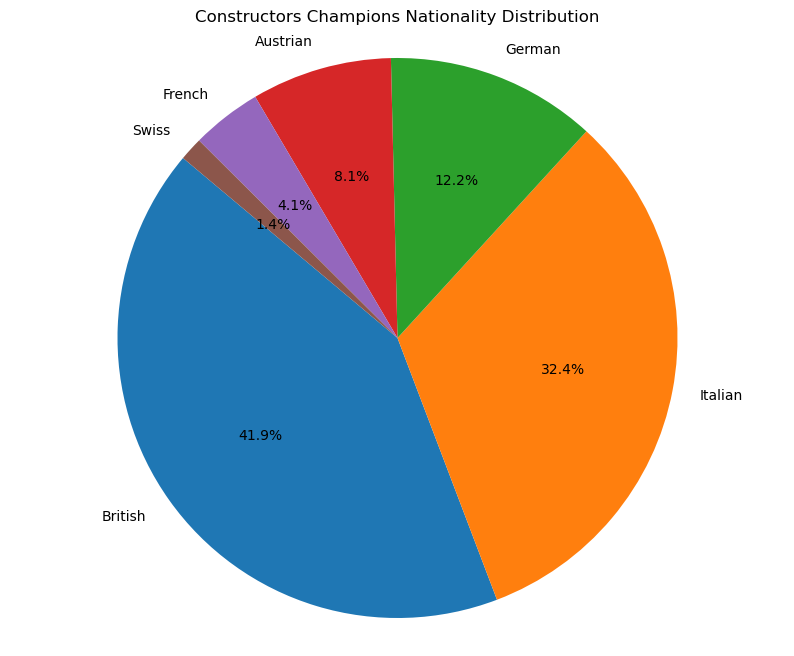

In [30]:
constructors_standings = constructors_standings[constructors_standings['position'] == 1]

constructors_nationality = constructors_standings.merge(constructors, on='constructorId', how='inner')
constructors_nationality = constructors_nationality[['nationality']]

nationality_count_df = constructors_nationality['nationality'].value_counts().reset_index()
nationality_count_df.columns = ['nationality', 'count']

plt.figure(figsize=(10, 8))
plt.pie(nationality_count_df['count'], labels=nationality_count_df['nationality'], autopct='%1.1f%%', startangle=140)
plt.title('Constructors Champions Nationality Distribution')
plt.axis('equal')

plt.show()
